<div style="background: linear-gradient(to bottom, #28DCAA, #006EC7); padding: 24px 28px; border-radius: 12px; color: white;">

# Model Comparison — Creative Generation 
Compares **Qwen** and **DeepSeek** coder models (dense & mixture-of-experts, 4-bit/8-bit quantized, run locally via MLX) on creative SVG generation.

</div>

In [1]:
import textwrap
import gc, json, re, sys, xml.etree.ElementTree as ET
from io import BytesIO
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from PIL import Image, ImageDraw
import cairosvg

sys.path.insert(0, "..")
from brand import BRAND, blue, purple, orange, green, pink, teal, brown, white, black, dark_bg

plt.style.use("dark_background")
mpl.rcParams.update({
    "figure.facecolor": dark_bg, "axes.facecolor": blue,
    "axes.edgecolor": blue, "axes.labelcolor": white,
    "xtick.color": white, "ytick.color": white, "text.color": white,
    "legend.facecolor": dark_bg, "legend.edgecolor": blue,
})

SYSTEM_PROMPT = (
    "You are an SVG icon generator. "
    "Given a description, output clean, valid SVG code for a single icon. "
    "Use currentColor for fill and stroke so the icon inherits its parent's color. "
    "Output only the SVG element — no explanation, no markdown fences."
)

MODELS = [
    {"id": "GPT-5.4"}, # US-gpt-5.4
    {"id": "mlx-community/Qwen2.5-Coder-1.5B-Instruct-4bit"},
    {"id": "mlx-community/Qwen2.5.1-Coder-7B-Instruct-4bit"},
    {"id": "mlx-community/Qwen2.5-Coder-14B-Instruct-4bit"},
    {"id": "mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit"}, 
    {"id": "mlx-community/DeepSeek-Coder-V2-Lite-Instruct-4bit"},
    {"id": "our-own"},  # placeholder for our own model
]

#<svg xmlns="http://www.w3.org/2000/svg" width="24" height="24" viewBox="0 0 24 24"><g fill="none" stroke="#000" stroke-linecap="round" stroke-width="1.5"><path stroke-linejoin="round" d="M5 16H3a1 1 0 0 0-1 1v.5a1 1 0 0 0 1 1h1a1 1 0 0 1 1 1v.5a1 1 0 0 1-1 1H2m6.5-5h1a1 1 0 0 1 1 1v3a1 1 0 0 1-1 1h-1a1 1 0 0 1-1-1v-3a1 1 0 0 1 1-1m5.5 0h1a1 1 0 0 1 1 1v3a1 1 0 0 1-1 1h-1a1 1 0 0 1-1-1v-3a1 1 0 0 1 1-1m8 0v5l-3.5-5v5"/><path d="M17 8A5 5 0 1 0 7 8a5 5 0 0 0 10 0Z"/><path stroke-linejoin="round" d="M13.5 8.5L12 8V5.5"/></g></svg>



for m in MODELS:
    m["name"] = m["id"].removeprefix("mlx-community/")

MODEL_COLORS = [pink, orange, green, teal, purple, brown, blue]  # one color per model, Parts 1 & 2

SAMPLE_N = 50  # Part 2 only: number of captioned icons used for metrics

print("Ready. Models:", [m['name'] for m in MODELS])


Ready. Models: ['GPT-5.4', 'Qwen2.5-Coder-1.5B-Instruct-4bit', 'Qwen2.5.1-Coder-7B-Instruct-4bit', 'Qwen2.5-Coder-14B-Instruct-4bit', 'Qwen3-Coder-30B-A3B-Instruct-4bit', 'DeepSeek-Coder-V2-Lite-Instruct-4bit', 'our-own']


In [2]:
import re, os
from dotenv import load_dotenv
load_dotenv("../.env")

def clean_svg(raw: str) -> str:
    raw = re.sub(r'```\w*', '', raw)
    raw = raw.replace('<|im_end|>', '')
    return raw.strip()


def generate_svgs_openai(model_id: str, prompts: list[str]) -> list[str]:
    from openai import OpenAI
    client = OpenAI(
        api_key=os.environ["OPENAI_API_KEY"],
        base_url=os.environ["OPENAI_API_BASE"],
    )
    results = []
    for prompt in prompts:
        response = client.chat.completions.create(
            model=model_id,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": prompt},
            ],
            max_tokens=2048,
            temperature=0.7,
        )
        results.append(clean_svg(response.choices[0].message.content or ""))
    print(f"  done ({len(results)} icons)")
    return results


def generate_svgs(model_cfg: dict, prompts: list[str]) -> list[str]:
    from mlx_lm import load, generate
    from mlx_lm.sample_utils import make_sampler
    print(f"Loading {model_cfg['name']} ...")
    model, tokenizer = load(model_cfg["id"], adapter_path=model_cfg.get("adapter"))
    results = []
    for prompt in prompts:
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": prompt},
        ]
        prompt_str = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        raw = generate(model, tokenizer, prompt=prompt_str,
                       max_tokens=2048,
                       sampler=make_sampler(temp=0.7), verbose=False)
        results.append(clean_svg(raw))
    del model, tokenizer
    gc.collect()
    print(f"  done ({len(results)} icons)")
    return results


CARD_SIZE     = 200
CORNER_RADIUS = 18
ICON_PADDING  = 20

def _hex_to_rgba(h: str, alpha: int = 255) -> tuple:
    h = h.lstrip("#")
    return (int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16), alpha)

def svg_to_card(svg: str, icon_color: str, label: str = "") -> "Image.Image | None":
    try:
        icon_size = CARD_SIZE - ICON_PADDING * 2
        svg_colored = svg.replace("currentColor", icon_color)
        svg_colored = re.sub(r'(fill|stroke)="(black|#000|#000000)"', rf'\1="{icon_color}"', svg_colored)
        png = cairosvg.svg2png(bytestring=svg_colored.encode(),
                               output_width=icon_size, output_height=icon_size)
        icon = Image.open(BytesIO(png)).convert("RGBA")

        card = Image.new("RGBA", (CARD_SIZE, CARD_SIZE), (0, 0, 0, 0))
        mask = Image.new("L", (CARD_SIZE, CARD_SIZE), 0)
        ImageDraw.Draw(mask).rounded_rectangle(
            [0, 0, CARD_SIZE - 1, CARD_SIZE - 1], radius=CORNER_RADIUS, fill=255
        )
        bg = Image.new("RGBA", (CARD_SIZE, CARD_SIZE), (255, 255, 255, 255))
        card.paste(bg, mask=mask)
        card.paste(icon, (ICON_PADDING, ICON_PADDING), icon)
        ImageDraw.Draw(card).rounded_rectangle(
            [0, 0, CARD_SIZE - 1, CARD_SIZE - 1],
            radius=CORNER_RADIUS,
            outline=_hex_to_rgba(icon_color),
            width=4,
        )
        return card
    except Exception as e:
        tag = f" [{label}]" if label else ""
        print(f"render error{tag}: {e}")
        return None


## Part 1 — Creative Generation

Images rendered at 128 px.

In [3]:
PROMPTS = [
    "Monochrome SVG icon of a light bulb",
    "Monochrome SVG icon of a robot head",
    "Monochrome SVG icon of a human-robot handshake",
    "Monochrome SVG icon of a multi-agent system",
]

In [4]:
import time

OPENAI_MODEL_ID = "US-gpt-5.4"  # name as registered in the Adesso AI Hub

creative_results: dict[str, list[str]] = {}
generation_times: dict[str, float] = {}
for cfg in MODELS:
    if cfg["id"] == "our-own":
        continue
    t0 = time.time()
    if cfg["id"] == "GPT-5.4":
        print(f"Calling {cfg['name']} via Adesso AI Hub ...")
        creative_results[cfg["name"]] = generate_svgs_openai(OPENAI_MODEL_ID, PROMPTS)
    else:
        creative_results[cfg["name"]] = generate_svgs(cfg, PROMPTS)
    elapsed = time.time() - t0
    generation_times[cfg["name"]] = elapsed
    print(f"  {cfg['name']}: {elapsed:.1f}s ({elapsed/len(PROMPTS):.1f}s/icon)")


Calling GPT-5.4 via Adesso AI Hub ...
  done (4 icons)
  GPT-5.4: 35.1s (8.8s/icon)


/Users/yauheniya.varabyova/Code/icongenai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Qwen2.5-Coder-1.5B-Instruct-4bit ...


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 99864.38it/s]


  done (4 icons)
  Qwen2.5-Coder-1.5B-Instruct-4bit: 28.2s (7.1s/icon)
Loading Qwen2.5.1-Coder-7B-Instruct-4bit ...


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 140853.49it/s]


  done (4 icons)
  Qwen2.5.1-Coder-7B-Instruct-4bit: 14.6s (3.6s/icon)
Loading Qwen2.5-Coder-14B-Instruct-4bit ...


Fetching 10 files: 100%|██████████| 10/10 [00:00<00:00, 90785.80it/s]


  done (4 icons)
  Qwen2.5-Coder-14B-Instruct-4bit: 38.8s (9.7s/icon)
Loading Qwen3-Coder-30B-A3B-Instruct-4bit ...


Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 25338.12it/s]


[WARNING] Generating with a model that requires 16384 MB which is close to the maximum recommended size of 18186 MB. This can be slow. See the documentation for possible work-arounds: https://github.com/ml-explore/mlx-lm/tree/main#large-models
[WARNING] Generating with a model that requires 16384 MB which is close to the maximum recommended size of 18186 MB. This can be slow. See the documentation for possible work-arounds: https://github.com/ml-explore/mlx-lm/tree/main#large-models
[WARNING] Generating with a model that requires 16384 MB which is close to the maximum recommended size of 18186 MB. This can be slow. See the documentation for possible work-arounds: https://github.com/ml-explore/mlx-lm/tree/main#large-models
[WARNING] Generating with a model that requires 16384 MB which is close to the maximum recommended size of 18186 MB. This can be slow. See the documentation for possible work-arounds: https://github.com/ml-explore/mlx-lm/tree/main#large-models
  done (4 icons)
  Qwen3

Fetching 11 files: 100%|██████████| 11/11 [00:00<00:00, 119526.80it/s]
`rope_parameters`'s factor field must be a float >= 1, got 40
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


  done (4 icons)
  DeepSeek-Coder-V2-Lite-Instruct-4bit: 40.1s (10.0s/icon)


In [5]:
# Debug: print raw model output to check if SVG is being generated
for model_name, svgs in creative_results.items():
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")
    for prompt, svg in zip(PROMPTS, svgs):
        print(f"\nPrompt: {prompt}")
        print(f"Output ({len(svg)} chars):")
        print(svg)
        #print("..." if len(svg) > 500 else "")


MODEL: GPT-5.4

Prompt: Monochrome SVG icon of a light bulb
Output (341 chars):
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="1.8" stroke-linecap="round" stroke-linejoin="round" aria-hidden="true">
  <path d="M12 3a6.5 6.5 0 0 0-4.6 11.1c.9.9 1.6 1.9 1.9 3H14.7c.3-1.1 1-2.1 1.9-3A6.5 6.5 0 0 0 12 3Z"/>
  <path d="M9.5 17.1h5"/>
  <path d="M10 20h4"/>
</svg>

Prompt: Monochrome SVG icon of a robot head
Output (549 chars):
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="1.8" stroke-linecap="round" stroke-linejoin="round" aria-hidden="true">
  <rect x="5" y="7" width="14" height="11" rx="3" ry="3"/>
  <path d="M12 3v4"/>
  <path d="M9 3h6"/>
  <circle cx="9" cy="12" r="1.2" fill="currentColor" stroke="none"/>
  <circle cx="15" cy="12" r="1.2" fill="currentColor" stroke="none"/>
  <path d="M9 15.5h6"/>
  <path d="M3.5 10.5H5"/>
  <path d="M19 10.5h1.5"/>
  <path d="M7 

render error [Qwen2.5-Coder-1.5B-Instruct-4bit / Monochrome SVG icon of a robot head]: unclosed token: line 69, column 4
render error [Qwen2.5-Coder-1.5B-Instruct-4bit / Monochrome SVG icon of a human-robot handshake]: unclosed token: line 2, column 0


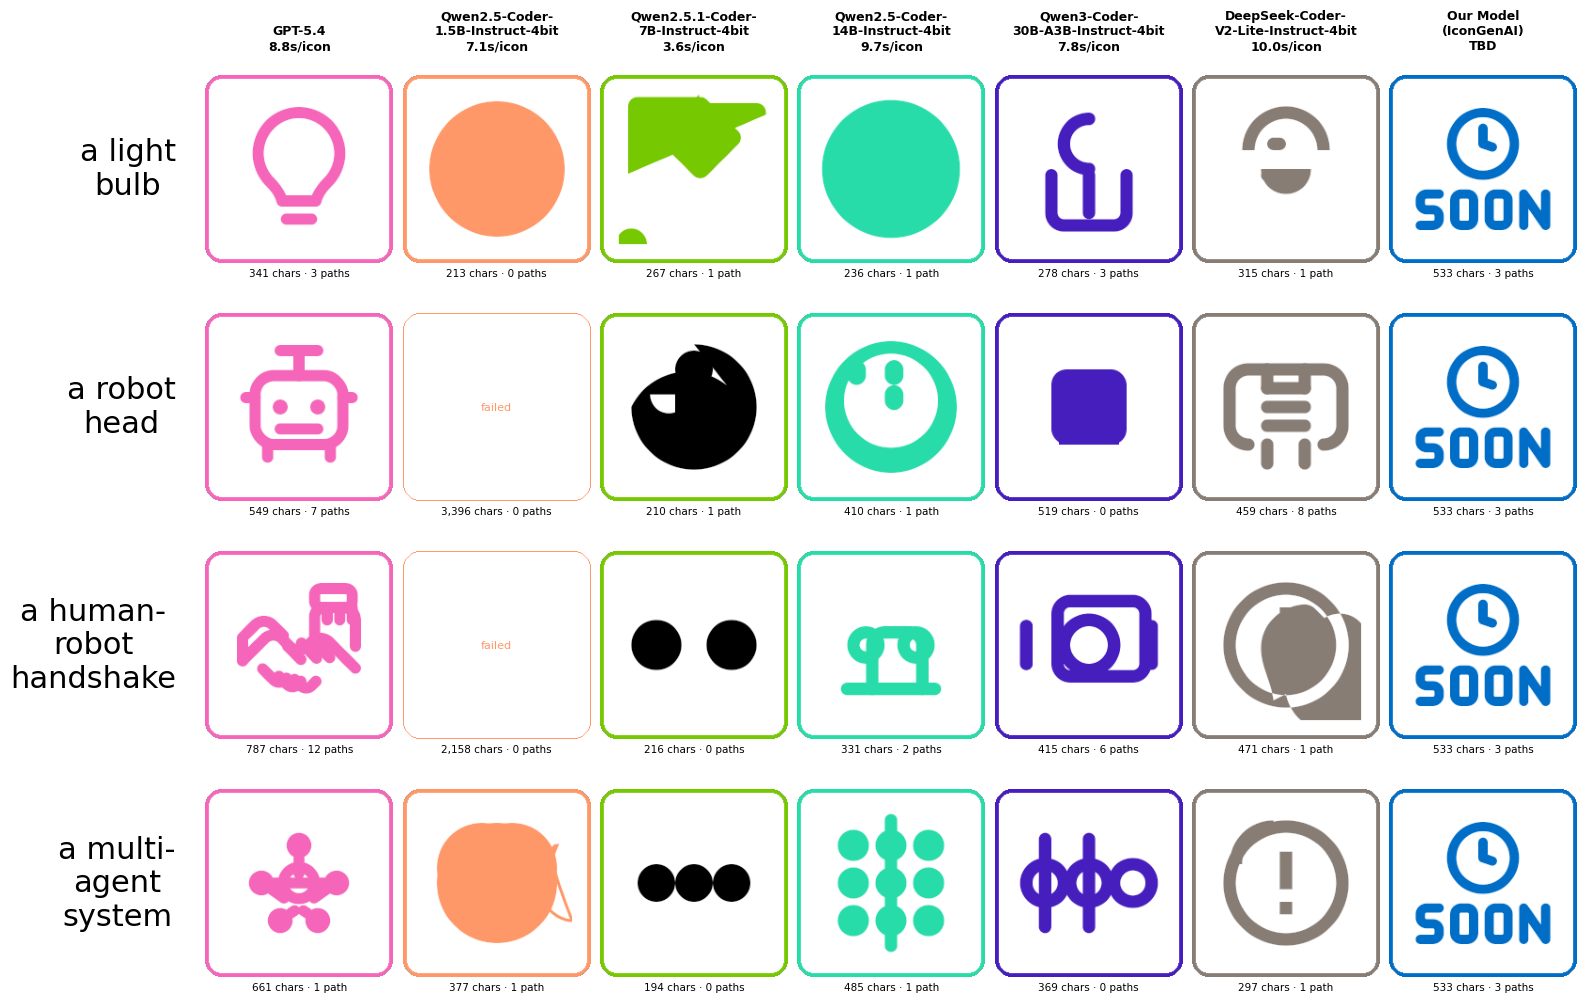

In [6]:
def _path_count(svg: str) -> int:
    try:
        root = ET.fromstring(svg)
        ns = root.tag.split("}")[0].lstrip("{") if "}" in root.tag else ""
        tag = f"{{{ns}}}path" if ns else "path"
        return len(root.findall(f".//{tag}"))
    except Exception:
        return 0

def _fmt_model_name(name: str) -> str:
    return re.sub(r'(Coder-)', r'\1\n', name)

_PLACEHOLDER_SVG = '<svg xmlns="http://www.w3.org/2000/svg" width="24" height="24" viewBox="0 0 24 24"><g fill="none" stroke="#000" stroke-linecap="round" stroke-width="1.5"><path stroke-linejoin="round" d="M5 16H3a1 1 0 0 0-1 1v.5a1 1 0 0 0 1 1h1a1 1 0 0 1 1 1v.5a1 1 0 0 1-1 1H2m6.5-5h1a1 1 0 0 1 1 1v3a1 1 0 0 1-1 1h-1a1 1 0 0 1-1-1v-3a1 1 0 0 1 1-1m5.5 0h1a1 1 0 0 1 1 1v3a1 1 0 0 1-1 1h-1a1 1 0 0 1-1-1v-3a1 1 0 0 1 1-1m8 0v5l-3.5-5v5"/><path d="M17 8A5 5 0 1 0 7 8a5 5 0 0 0 10 0Z"/><path stroke-linejoin="round" d="M13.5 8.5L12 8V5.5"/></g></svg>'
creative_results.setdefault("our-own", [_PLACEHOLDER_SVG] * len(PROMPTS))
generation_times.setdefault("our-own", None)

n_models  = len(MODELS)
n_prompts = len(PROMPTS)

# _TOP is shared between subplots_adjust and column header placement
# so all headers land at exactly the same y regardless of content
_TOP = 0.84

Path("output").mkdir(exist_ok=True)

fig, axes = plt.subplots(
    n_prompts, n_models,
    figsize=(n_models * 2.8, n_prompts * 2.8 + 1.6),
    facecolor="white", squeeze=False,
)
fig.subplots_adjust(left=0.20, top=_TOP, hspace=0.08, wspace=0.05)

col_header_data = []  # collect (display_name, timing_str, x_center) during loop

for c_idx, cfg in enumerate(MODELS):
    is_ours    = cfg["id"] == "our-own"
    svgs       = creative_results[cfg["name"]]
    avg_t      = generation_times[cfg["name"]]
    timing_str = f"{avg_t / len(PROMPTS):.1f}s/icon" if avg_t is not None else "TBD"
    display_name = "Our Model\n(IconGenAI)" if is_ours else _fmt_model_name(cfg["name"])

    for r, (svg, prompt) in enumerate(zip(svgs, PROMPTS)):
        ax = axes[r][c_idx]
        ax.set_facecolor("white")
        model_color = MODEL_COLORS[c_idx % len(MODEL_COLORS)]
        card = svg_to_card(svg, model_color, label=f"{cfg['name']} / {prompt}")
        if card is None:
            # blank outlined card so the border is always shown
            card = Image.new("RGBA", (CARD_SIZE, CARD_SIZE), (255, 255, 255, 255))
            ImageDraw.Draw(card).rounded_rectangle(
                [0, 0, CARD_SIZE - 1, CARD_SIZE - 1],
                radius=CORNER_RADIUS, outline=_hex_to_rgba(model_color), width=1,
            )
            ax.text(0.5, 0.5, "failed", ha="center", va="center",
                    color=model_color, fontsize=8, transform=ax.transAxes)
        ax.imshow(card)
        ax.axis("off")

        n_chars = len(svg)
        n_paths = _path_count(svg)
        ax.text(0.5, -0.03, f"{n_chars:,} chars · {n_paths} path{'s' if n_paths != 1 else ''}",
                ha="center", va="top", fontsize=7.5, color="black",
                transform=ax.transAxes, clip_on=False)

        if c_idx == 0:
            short = prompt.replace("Monochrome SVG icon of ", "")
            wrapped = "\n".join(textwrap.wrap(short, width=10))
            pos = ax.get_position()
            fig.text(
                pos.x0 - 0.015, pos.y0 + pos.height / 2, wrapped,
                ha="right", va="center", fontsize=22, color="black",
                rotation=0, multialignment="center",
            )

    pos0 = axes[0][c_idx].get_position()
    col_header_data.append((display_name, timing_str, pos0.x0 + pos0.width / 2))

# Place all column headers at the same fixed y = _TOP + gap
for display_name, timing_str, x_center in col_header_data:
    fig.text(
        x_center, _TOP + 0.005,
        f"{display_name}\n{timing_str}",
        ha="center", va="bottom", fontsize=9, color="black",
        fontweight="bold", multialignment="center",
    )

plt.savefig("output/model_comparison_grid.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


## Part 2 — Pilot Fine-tuning Comparison

Visual comparison of reference icons vs. zero-shot baseline vs. LoRA fine-tuned model (Qwen2.5-Coder-1.5B, 10k training icons, 3 epochs).

In [6]:
import json, re, textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from io import BytesIO
from pathlib import Path
from PIL import Image, ImageDraw
import cairosvg

# ── Load results ──────────────────────────────────────────────────────────────
GEN_PATH  = Path("../results/pilot/generated.jsonl")
ZERO_PATH = Path("../results/pilot/zeroshot.jsonl")

def load_jsonl(p):
    return [json.loads(l) for l in open(p) if l.strip()]

gen_rows  = load_jsonl(GEN_PATH)
zero_rows = load_jsonl(ZERO_PATH)

# Use records where both files have results
N_POOL = min(100, len(gen_rows), len(zero_rows))
gen_rows  = gen_rows[:N_POOL]
zero_rows = zero_rows[:N_POOL]

# Skip first 5 — curriculum-ordered data starts with trivial 1-path shapes
# that render as solid filled squares. Start from index 5 for visual variety.
MIN_IDX  = 5
N_SHOW   = 7
indices  = np.linspace(MIN_IDX, N_POOL - 1, N_SHOW, dtype=int)
records  = [
    {
        "prompt":    gen_rows[i]["prompt"].replace("Generate an SVG icon: ", ""),
        "reference": gen_rows[i]["reference_svg"],
        "zeroshot":  zero_rows[i]["generated_svg"],
        "finetuned": gen_rows[i]["generated_svg"],
    }
    for i in indices
]
print(f"Pool: {N_POOL} icons  |  Indices: {indices.tolist()}")
for r in records:
    print(f"  · {r['prompt'][:70]}")

Pool: 100 icons  |  Indices: [5, 20, 36, 52, 67, 83, 99]
  · task icon with visible circle, filled style
  · leaf inside square, minimalist icon
  · modern drum set icon in line style
  · full-moon face with closed eyes, simple line art
  · fast timer icon with bold lines
  · thumbs-up gesture, filled black icon
  · line-style shopping cart with wheels


Indices: [7, 16, 21, 50, 54, 86, 98]
  · table tennis player in action, line-style icon
  · inbox-down icon with arrow pointing down
  · Smart optimization, atom-like symbol, line style
  · checkmark next to file code icon
  · Help icon with headphones, customer support symbol
  · wavy dollar bill with gray fill and curved edges
  · circular icon with heart, music or collection symbol


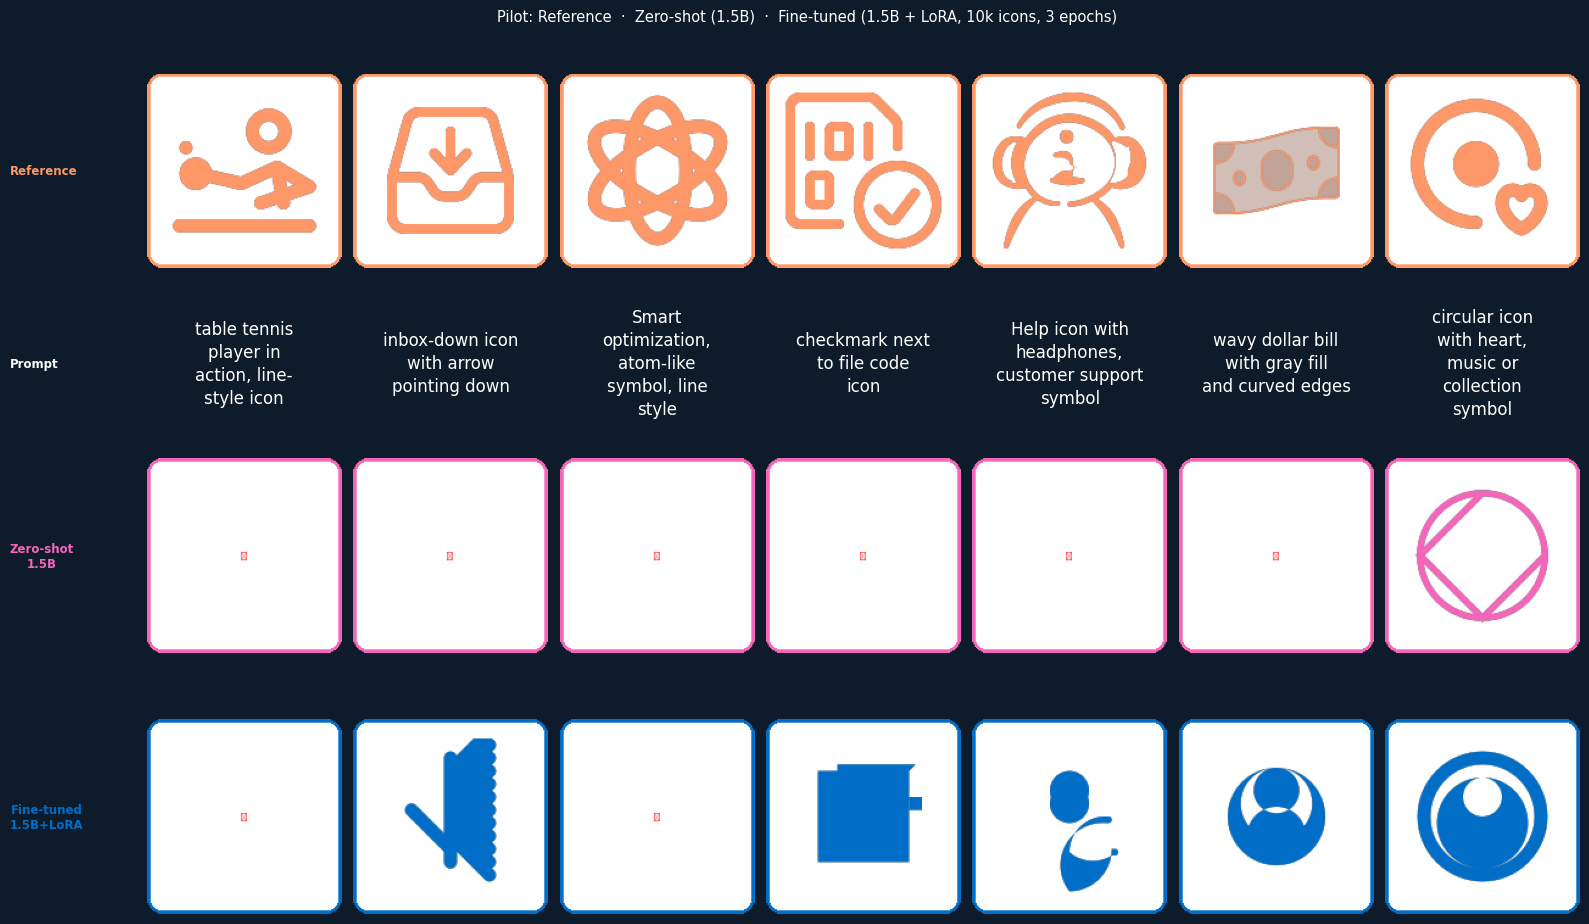

Saved → output/pilot_comparison_grid.png


In [9]:
import random

# ── Sample icons — random each rerun ─────────────────────────────────────────
# Skip first MIN_IDX (trivial 1-path curriculum icons that render as solid squares)
MIN_IDX = 5
pool    = list(range(MIN_IDX, N_POOL))
indices = sorted(random.sample(pool, min(N_SHOW, len(pool))))
records = [
    {
        "prompt":    gen_rows[i]["prompt"].replace("Generate an SVG icon: ", ""),
        "reference": gen_rows[i]["reference_svg"],
        "zeroshot":  zero_rows[i]["generated_svg"],
        "finetuned": gen_rows[i]["generated_svg"],
    }
    for i in indices
]
print(f"Indices: {indices}")
for r in records:
    print(f"  · {r['prompt'][:70]}")

# ── Render helpers ────────────────────────────────────────────────────────────
BG       = "#0D1B2A"
CARD_SZ  = 160
ICON_PAD = 16
CORNER   = 12

def _rgba(h, a=255):
    h = h.lstrip("#")
    return (int(h[0:2],16), int(h[2:4],16), int(h[4:6],16), a)

def make_card(svg_text, color):
    m = re.search(r"(<svg[\s\S]*?</svg>)", svg_text, re.IGNORECASE)
    svg = m.group(1) if m else svg_text
    svg = svg.replace("currentColor", color)
    svg = re.sub(r'(fill|stroke)="(black|#000|#000000)"', rf'\1="{color}"', svg)

    icon_sz = CARD_SZ - ICON_PAD * 2
    card = Image.new("RGBA", (CARD_SZ, CARD_SZ), (0, 0, 0, 0))
    mask = Image.new("L",    (CARD_SZ, CARD_SZ), 0)
    ImageDraw.Draw(mask).rounded_rectangle([0, 0, CARD_SZ-1, CARD_SZ-1], radius=CORNER, fill=255)
    card.paste(Image.new("RGBA", (CARD_SZ, CARD_SZ), (255, 255, 255, 255)), mask=mask)

    try:
        png  = cairosvg.svg2png(bytestring=svg.encode(), output_width=icon_sz, output_height=icon_sz)
        icon = Image.open(BytesIO(png)).convert("RGBA")
        card.paste(icon, (ICON_PAD, ICON_PAD), icon)
    except Exception:
        ImageDraw.Draw(card).text(
            (CARD_SZ//2, CARD_SZ//2), "✕", fill=_rgba("#FF4444"), anchor="mm"
        )

    ImageDraw.Draw(card).rounded_rectangle(
        [0, 0, CARD_SZ-1, CARD_SZ-1], radius=CORNER, outline=_rgba(color), width=3
    )
    return card

# ── Row config ────────────────────────────────────────────────────────────────
ROW_META = [
    ("Reference",            "#FF9868", "reference"),
    ("Prompt",               "#FFFFFF", "prompt"),
    ("Zero-shot\n1.5B",      "#F566BA", "zeroshot"),
    ("Fine-tuned\n1.5B+LoRA","#006EC7", "finetuned"),
]

fig = plt.figure(figsize=(N_SHOW * 2.3, 4 * 2.4), facecolor=BG)
gs  = gridspec.GridSpec(
    4, N_SHOW, figure=fig,
    height_ratios=[2.2, 0.75, 2.2, 2.2],
    hspace=0.30, wspace=0.06,
    left=0.09, right=0.98, top=0.91, bottom=0.02,
)

col0_axes = {}

for col_i, rec in enumerate(records):
    for row_i, (label, color, key) in enumerate(ROW_META):
        ax = fig.add_subplot(gs[row_i, col_i])
        ax.set_facecolor(BG)
        ax.axis("off")

        if col_i == 0:
            col0_axes[row_i] = ax

        if key == "prompt":
            wrapped = "\n".join(textwrap.wrap(rec["prompt"], width=16))
            ax.text(0.5, 0.5, wrapped,
                    ha="center", va="center", fontsize=12, color=color,
                    transform=ax.transAxes, multialignment="center", linespacing=1.35)
        else:
            ax.imshow(make_card(rec[key], color))

for row_i, (label, color, _) in enumerate(ROW_META):
    pos = col0_axes[row_i].get_position()
    fig.text(
        0.005, pos.y0 + pos.height / 2, label,
        ha="left", va="center", fontsize=8.5, color=color,
        fontweight="bold", multialignment="center",
    )

fig.suptitle(
    "Pilot: Reference  ·  Zero-shot (1.5B)  ·  Fine-tuned (1.5B + LoRA, 10k icons, 3 epochs)",
    color="white", fontsize=10.5, y=0.97,
)

Path("output").mkdir(exist_ok=True)
plt.savefig("output/pilot_comparison_grid.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved → output/pilot_comparison_grid.png")